In [1]:
# Library imports
import polars as pl
import os
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load position info
video_df = pl.read_csv(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\full_video_dataframe.csv")
homie_path = r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\homings\homings_obj.pkl"
with open(homie_path, "rb") as dill_file:
    homings = pickle.load(dill_file)
frame_by_cluster_matrix = np.load(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\frame_by_synthetic_cluster_matrix.npy")
video_and_spike_data = pl.read_parquet(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\synthetic_video_spike_count_df")

In [3]:
print(frame_by_cluster_matrix)
print(frame_by_cluster_matrix.shape)
print(video_df.shape)
print(video_df.columns)

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [30. 20.  0. ... 10.  0.  0.]
 [30. 20.  0. ... 10.  0.  0.]
 [10. 20.  0. ...  0.  0.  0.]]
(731210, 148)
(731210, 177)
['frames', 'hdir', 'mouse_x_position', 'mouse_y_position', 'OutofshelterIdx', 'EscapePeriod', 'shelter', 'barrier_present', 'barrier_flipped', 'hsa', 'h_bar_north_a', 'h_bar_south_a', 'h_bar_centre_a', 'head_randP_0', 'head_randP_1', 'head_randP_2', 'head_randP_3', 'head_randP_4', 'head_randP_5', 'head_randP_6', 'head_randP_7', 'head_randP_8', 'head_randP_9', 'head_randP_10', 'head_randP_11', 'head_randP_12', 'head_randP_13', 'head_randP_14', 'head_randP_15', 'head_randP_16', 'head_randP_17', 'head_randP_18', 'head_randP_19', 'head_randP_20', 'head_randP_21', 'head_randP_22', 'head_randP_23', 'head_randP_24', 'head_randP_25', 'head_randP_26', 'head_randP_27', 'head_randP_28', 'head_randP_29', 'head_randP_30', 'head_randP_31', 'head_randP_32', 'head_randP_33', 'head_rand

In [4]:
# Because of memory constraints, let's only keep the columns we need for this module
COLUMNS_TO_KEEP = [
    "frames",
    "mouse_x_position",
    "mouse_y_position",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "hdir",
    "barrier_present",
    "barrier_flipped",
    'hsa', 
    'h_bar_north_a', 
    'h_bar_south_a',
]

# Select some columns to keep
 

In [5]:
video_df = video_df.select(COLUMNS_TO_KEEP)  # Prevents memory issues and computer crashes
# video_df = video_df.filter((video_df["barrier_present"] == True) & (video_df["barrier_flipped"] == False))
print(video_df)
print(video_df.columns)

shape: (731210, 12)
┌────────┬────────────┬────────────┬────────────┬─────┬────────────┬───────────┬────────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ Outofshelt ┆ ... ┆ barrier_fl ┆ hsa       ┆ h_bar_nort ┆ h_bar_sout │
│ ---    ┆ sition     ┆ sition     ┆ erIdx      ┆     ┆ ipped      ┆ ---       ┆ h_a        ┆ h_a        │
│ i64    ┆ ---        ┆ ---        ┆ ---        ┆     ┆ ---        ┆ f64       ┆ ---        ┆ ---        │
│        ┆ f64        ┆ f64        ┆ bool       ┆     ┆ bool       ┆           ┆ f64        ┆ f64        │
╞════════╪════════════╪════════════╪════════════╪═════╪════════════╪═══════════╪════════════╪════════════╡
│ 1      ┆ 282.676091 ┆ 245.210752 ┆ true       ┆ ... ┆ false      ┆ -2.340929 ┆ -2.884015  ┆ -1.619578  │
│ 2      ┆ 282.707823 ┆ 245.301877 ┆ true       ┆ ... ┆ false      ┆ -2.332812 ┆ -2.876004  ┆ -1.611392  │
│ 3      ┆ 282.735861 ┆ 245.385096 ┆ true       ┆ ... ┆ false      ┆ -2.32511  ┆ -2.868389  ┆ -1.603632  │
│ 4      ┆ 282.75

In [6]:
homings

Homings(onset_frames=array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), offset_frames=array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 2986

In [7]:
onset_frames = homings.onset_frames

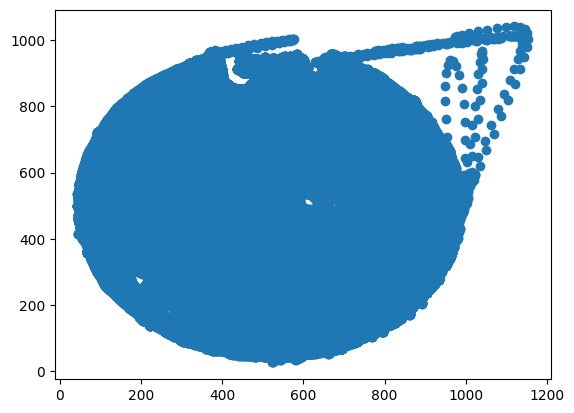

In [8]:
plt.scatter(video_df["mouse_x_position"], video_df["mouse_y_position"])

## A function to check the attributes required from the homing object exsists and to put them into a neat dictionary

In [9]:
def access_homing_attributes(homings_obj: object) -> dict:
    """Return a dictionary of verified homing attributes"""
    try:
        onset_frames = homings_obj.onset_frames
        offset_frames = homings_obj.offset_frames
    except AttributeError:
        raise AttributeError("The homings object does not have the required attributes - Something upstream is wrong with the homings object")
    assert len(onset_frames) == len(offset_frames), "The onset and offset frames are not the same length - Something is wrong with the homings object"
    return {"onset_frames": onset_frames, "offset_frames": offset_frames}

In [10]:
dic = access_homing_attributes(homings)
print(dic)
print(len(dic["onset_frames"]))

{'onset_frames': array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), 'offset_frames': array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 29862

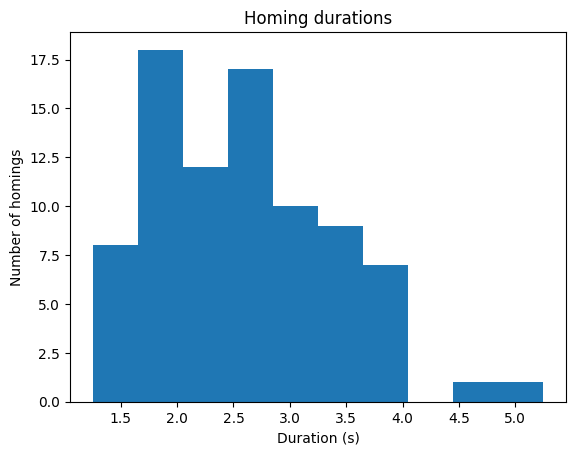

In [11]:
def plot_homing_durations(homings_dic) -> None:
    """Plot the durations of homings"""
    onset_frames = homings_dic["onset_frames"]
    offset_frames = homings_dic["offset_frames"]
    durations = (offset_frames - onset_frames) / 40 # 40 fps
    plt.hist(durations)
    plt.xlabel("Duration (s)")
    plt.ylabel("Number of homings")
    plt.title("Homing durations")
    plt.show()
plot_homing_durations(dic)

In [12]:
def check_frames_increment_by_one(arr):
    """A test to check that frames increment by 1 and as such is continuous ensuring no frames are skipped"""
    # Check each element to see if it increments by 1
    for i in range(len(arr) - 1):
        if arr[i + 1] - arr[i] != 1:
            return False
    return True

### Create some distance bins to see distribution across y axis

[  0.          25.80645161  51.61290323  77.41935484 103.22580645
 129.03225806 154.83870968 180.64516129 206.4516129  232.25806452
 258.06451613 283.87096774 309.67741935 335.48387097 361.29032258
 387.09677419 412.90322581 438.70967742 464.51612903 490.32258065
 516.12903226 541.93548387 567.74193548 593.5483871  619.35483871
 645.16129032 670.96774194 696.77419355 722.58064516 748.38709677
 774.19354839 800.        ]


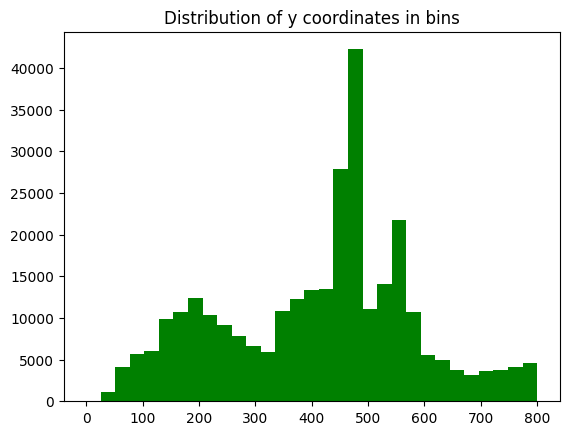

In [13]:
ycoords = video_df["mouse_y_position"]
# plt.hist(ycoords, bins=16)
# now remove y coordinats greater than 800
ycoords = ycoords.filter(ycoords < 800)
# plt.hist(ycoords, bins=16)
plt.title("Distribution of y coordinates in bins")
# 8 bins would be 10cm each, so 16 bins would be 5cm each
bins = np.linspace(0, 800, 32) # Remove near shelter as there are a lot of frames there
plt.hist(ycoords, bins=bins, color="green") # These are the defined bins
print(bins)
# NOTE there seems to be more frames around the subgoal probably due to the turn, so we should
# probably sample the frames more uniformly across bins depending on how we want to analyse the data
# TODO - Speak to jas about how she uniformly samples across bins

In [14]:
def extract_homing_info(dic, video_df):
    """Extract homing info from video_df"""
    onset_frames = dic["onset_frames"]
    offset_frames = dic["offset_frames"]
    homing_info = []
    for onset, offset in zip(onset_frames, offset_frames):
        homing = video_df[onset:offset]
        homing = homing.select(["frames", "mouse_x_position", "mouse_y_position", "hdir",  'hsa', 'h_bar_north_a', 'h_bar_south_a',])
        homing_info.append(homing)
        
    # Check the frame column of each homing information increments uniformly by 1 such that no frames are missed
    for homing in homing_info:
        assert check_frames_increment_by_one(homing["frames"].to_numpy()), "Frames are missing in the homing information"
    
    return homing_info
info = extract_homing_info(dic, video_df)
print(info[3])

shape: (82, 7)
┌────────┬────────────────┬────────────────┬───────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positi ┆ mouse_y_positi ┆ hdir      ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ on             ┆ on             ┆ ---       ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---            ┆ ---            ┆ f64       ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64            ┆ f64            ┆           ┆           ┆               ┆               │
╞════════╪════════════════╪════════════════╪═══════════╪═══════════╪═══════════════╪═══════════════╡
│ 12527  ┆ 866.017856     ┆ 227.719817     ┆ 1.632464  ┆ 2.624716  ┆ 1.96584       ┆ 2.876886      │
│ 12528  ┆ 865.81501      ┆ 228.097034     ┆ 1.690158  ┆ 2.567671  ┆ 1.908143      ┆ 2.821232      │
│ 12529  ┆ 865.581416     ┆ 228.560205     ┆ 1.748635  ┆ 2.509928  ┆ 1.849622      ┆ 2.765109      │
│ 12530  ┆ 865.333292     ┆ 229.14716      ┆ 1.806196  ┆ 2.453135  ┆ 1.79189

shape: (109, 7)
┌────────┬────────────────┬────────────────┬───────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positi ┆ mouse_y_positi ┆ hdir      ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ on             ┆ on             ┆ ---       ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---            ┆ ---            ┆ f64       ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64            ┆ f64            ┆           ┆           ┆               ┆               │
╞════════╪════════════════╪════════════════╪═══════════╪═══════════╪═══════════════╪═══════════════╡
│ 437105 ┆ 545.473205     ┆ 97.314552      ┆ 1.248201  ┆ -2.841595 ┆ 2.846737      ┆ -2.29099      │
│ 437106 ┆ 545.226088     ┆ 96.851737      ┆ 1.224059  ┆ -2.817909 ┆ 2.870676      ┆ -2.267845     │
│ 437107 ┆ 544.985976     ┆ 97.119383      ┆ 1.19773   ┆ -2.792178 ┆ 2.895581      ┆ -2.241672     │
│ 437108 ┆ 544.826798     ┆ 98.292549      ┆ 1.166649  ┆ -2.761971 ┆ 2.9235

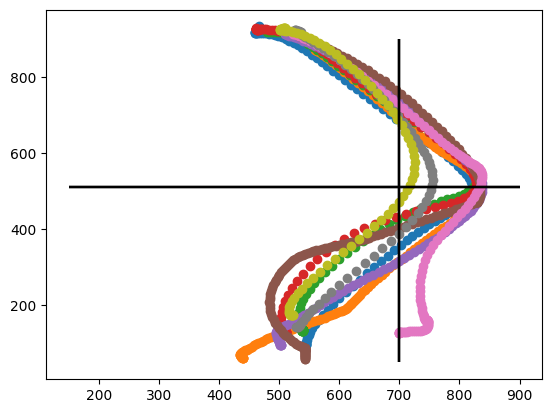

In [15]:
def select_similar_homings(info):
    """
    
    -- Similar time periods
    -- Similar mouse positions
    -- Similar targets

    Raises:
        NotImplementedError: _description_
    """
    # HARDCORE MODE - we like it rough and tough
    xcoordinate_min = 300
    xcoordinate_max = 700
    ycoordinate_min = 200
    ycoordinate_end_min = 750
    x_middle_chunk_min = 400
    x_middle_chunk_max = 600
    extracted_info = []
    for idx, homing in enumerate(info):
        
        # check if mouse x position is within the range - STARTS FARTS ONLY 
        start_x = homing["mouse_x_position"][0]
        start_y = homing["mouse_y_position"][0]
        
        # Starts in a similar space
        if start_x > xcoordinate_min and start_x < xcoordinate_max and start_y < ycoordinate_min:
            
            #Ends in a similar space
            if homing["mouse_y_position"][-1] > ycoordinate_end_min:
                
                # middle of frames is in a similar space
                middle_x = homing["mouse_x_position"][int(len(homing) / 2)]
                if middle_x < x_middle_chunk_min or middle_x > x_middle_chunk_max:
                    # plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                    # plt.hlines(y=512, xmin=150, xmax=900, color="k")
                    
                    # CHOOSE ONE SIDE
                    if middle_x > 700:
                        plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                        plt.hlines(y=512, xmin=150, xmax=900, color="k")
                        plt.vlines(x=700, ymin=50, ymax=900, color="k")
                    
                    
                        extracted_info.append(homing)
                    
    return extracted_info

extracted_info =  select_similar_homings(info)
print(extracted_info[0])
print(len(extracted_info))

# Plot the hdir arrwos at each point

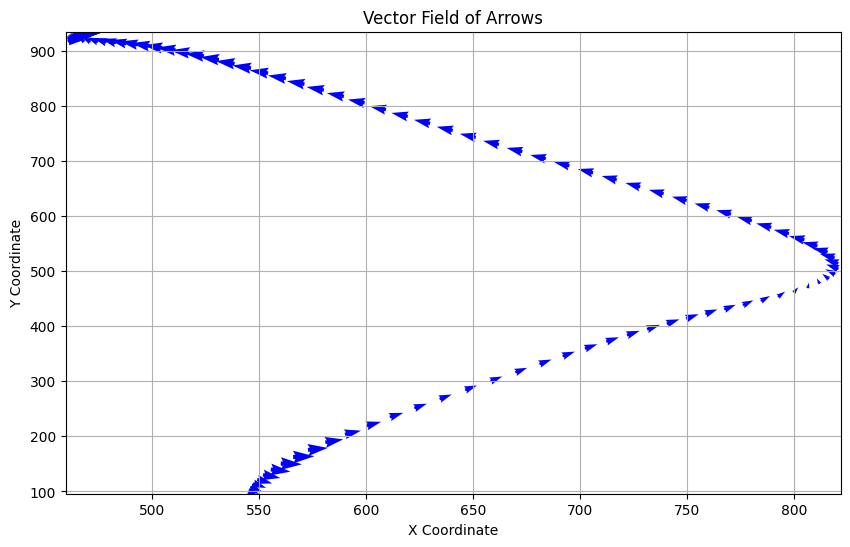

In [16]:
length = 20
dx = length * np.cos(extracted_info[0]["hdir"])
dy = length * -np.sin(extracted_info[0]["hdir"])
plt.figure(figsize=(10, 6))
xs = extracted_info[0]["mouse_x_position"]
ys = extracted_info[0]["mouse_y_position"]
plt.quiver(xs, ys, dx, dy, angles='xy', scale_units='xy', scale=2, color='blue')
plt.xlim(xs.min() - 1, xs.max() + 1)
plt.ylim(ys.min() - 1, ys.max() + 1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Vector Field of Arrows')
plt.grid(True)
plt.show()


## Compute the predictor


shape: (109, 8)
┌────────┬────────────┬────────────┬───────────┬───────────┬────────────┬──────────────┬───────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ hdir      ┆ hsa       ┆ h_bar_nort ┆ h_bar_south_ ┆ predictor │
│ ---    ┆ sition     ┆ sition     ┆ ---       ┆ ---       ┆ h_a        ┆ a            ┆ ---       │
│ i64    ┆ ---        ┆ ---        ┆ f64       ┆ f64       ┆ ---        ┆ ---          ┆ f64       │
│        ┆ f64        ┆ f64        ┆           ┆           ┆ f64        ┆ f64          ┆           │
╞════════╪════════════╪════════════╪═══════════╪═══════════╪════════════╪══════════════╪═══════════╡
│ 437105 ┆ 545.473205 ┆ 97.314552  ┆ 1.248201  ┆ -2.841595 ┆ 2.846737   ┆ -2.29099     ┆ 0.094751  │
│ 437106 ┆ 545.226088 ┆ 96.851737  ┆ 1.224059  ┆ -2.817909 ┆ 2.870676   ┆ -2.267845    ┆ 0.095435  │
│ 437107 ┆ 544.985976 ┆ 97.119383  ┆ 1.19773   ┆ -2.792178 ┆ 2.895581   ┆ -2.241672    ┆ 0.096351  │
│ 437108 ┆ 544.826798 ┆ 98.292549  ┆ 1.166649  ┆ -2.761971 ┆ 2.923594   ┆ -

C:\Users\laurence\AppData\Local\Temp\ipykernel_16964\2567402216.py:43: DeprecationWarning: `DataFrame.with_column` has been renamed; this redirect is temporary, please use `.with_columns` instead
  homing = homing.with_column(pl.Series("predictor", predictor))


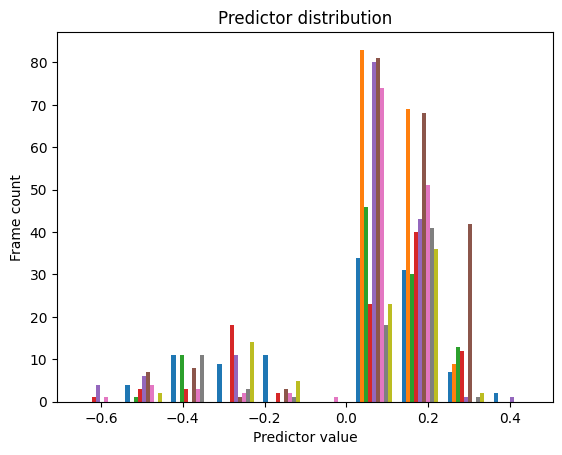

In [33]:
import numpy as np
import polars as pl

predictors = []

def circular_difference(angle1, angle2):
    diff = np.arctan2(np.sin(angle1 - angle2), np.cos(angle1 - angle2))
    return diff
    
def circular_sum(angle1, angle2):
    sum = np.arctan2(np.sin(angle1 + angle2), np.cos(angle1 + angle2))
    return (2*np.pi) - sum # Arctan2 returns shortest angle, so we need to subtract from 2pi to get the correct angle

def compute_predictor(hsa, h_bar_north_a):
    numerator = circular_difference(hsa, h_bar_north_a)
    denominator = circular_sum(hsa, h_bar_north_a)
    return numerator / denominator

# Unit tests
test_hsa = np.array([0, np.pi, np.pi])
test_angle = np.array([np.pi, 0])
test_result = compute_predictor(test_hsa, test_angle)
assert test_result[0] == -1, "Test 1 failed"
assert test_result[1] == 1, "Test 2 failed"

homing_data = {}
for idx, homing in enumerate(extracted_info):
    hsa = homing["hsa"].to_numpy().copy()
    h_bar_north_a = homing["h_bar_north_a"].to_numpy().copy()
    
    # Quality check
    # Check arrays are not above or below -pi and pi
    assert np.all(hsa >= -np.pi) and np.all(hsa <= np.pi), "hsa values are not within the range of -pi and pi"
    assert np.all(h_bar_north_a >= -np.pi) and np.all(h_bar_north_a <= np.pi), "h_bar_north_a values are not within the range of -pi and pi"
    
    # if values negative radians then add 2pi to make them positive
    # turn negative radians into positive radians to make them easier to work with
    hsa[hsa < 0] += 2 * np.pi
    h_bar_north_a[h_bar_north_a < 0] += 2 * np.pi
    
    predictor = compute_predictor(hsa, h_bar_north_a)
    predictors.append(predictor)
    homing = homing.with_column(pl.Series("predictor", predictor))
    homing_data[idx] = homing

# Example output
# # remove row limits to see all the data
pl.Config.set_tbl_rows(100)

print(homing_data[0])  # Display the data with predictors for the first dataset
plt.hist(predictors)
plt.title("Predictor distribution")
plt.xlabel("Predictor value")
plt.ylabel("Frame count")
plt.show()


# Plot predictor for first homing

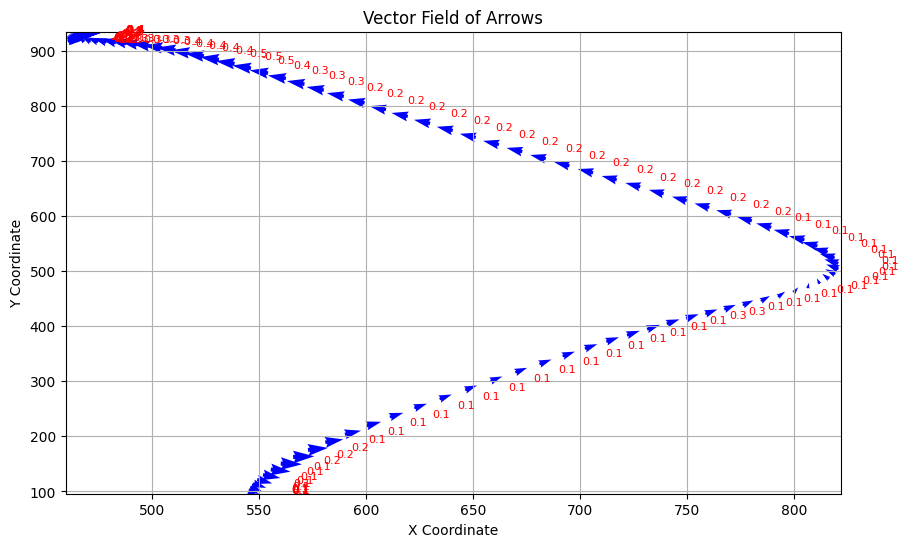

In [30]:
length = 20
dx = length * np.cos(homing_data[0]["hdir"])
dy = length * -np.sin(homing_data[0]["hdir"])
plt.figure(figsize=(10, 6))
xs = homing_data[0]["mouse_x_position"]
ys = homing_data[0]["mouse_y_position"]
plt.quiver(xs, ys, dx, dy, angles='xy', scale_units='xy', scale=2, color='blue')

df = homing_data[0].to_pandas()
for i, row in df.iterrows():
    plt.text(x = row['mouse_x_position'] + 20, 
             y = row['mouse_y_position'], 
             s = str(np.around(row['predictor'], 1)), 
             color='red',
             fontsize=8)

plt.xlim(xs.min() - 1, xs.max() + 1)
plt.ylim(ys.min() - 1, ys.max() + 1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Vector Field of Arrows')
plt.grid(True)
plt.show()

# Extract predictor across all homings and get predictor stats

The mean, median, std and IQR of the predictor are:  0.07493933753853435 0.11474564484533466 0.18103339318089676 0.07739514448900958


Text(0.5, 1.0, 'Distribution of predictors on log scale')

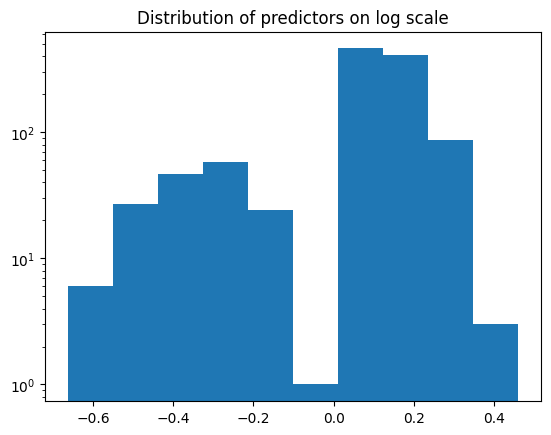

In [21]:
# Loop through the homing data and create a new array of all the predictors together
extracted_predictor = []
for idx, homing in enumerate(homing_data.values()):
    predictor = homing["predictor"]
    extracted_predictor.append(predictor.to_numpy())
flatten_extracted_predictor = np.concatenate(extracted_predictor)

# Pull at distribution statistics
median = np.nanmedian(flatten_extracted_predictor)
iqr = np.nanpercentile(flatten_extracted_predictor, 75) - np.nanpercentile(flatten_extracted_predictor, 25)
mean = np.nanmean(flatten_extracted_predictor)
std = np.nanstd(flatten_extracted_predictor)
print("The mean, median, std and IQR of the predictor are: ", mean, median, std, iqr)

# Plot the distribution of the predictors
plt.hist(flatten_extracted_predictor)
plt.yscale('log')
plt.title("Distribution of predictors on log scale")

### Because the min and max of the index is so large, let's normalise (min -462, max 3395)

shape: (6, 9)
┌────────┬────────────┬────────────┬──────────┬───┬────────────┬────────────┬─────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ hdir     ┆ h ┆ h_bar_nort ┆ h_bar_sout ┆ predict ┆ normalised │
│ ---    ┆ sition     ┆ sition     ┆ ---      ┆ s ┆ h_a        ┆ h_a        ┆ or      ┆ _predictor │
│ i64    ┆ ---        ┆ ---        ┆ f64      ┆ a ┆ ---        ┆ ---        ┆ ---     ┆ ---        │
│        ┆ f64        ┆ f64        ┆          ┆ - ┆ f64        ┆ f64        ┆ f64     ┆ f64        │
│        ┆            ┆            ┆          ┆ - ┆            ┆            ┆         ┆            │
│        ┆            ┆            ┆          ┆ - ┆            ┆            ┆         ┆            │
│        ┆            ┆            ┆          ┆ f ┆            ┆            ┆         ┆            │
│        ┆            ┆            ┆          ┆ 6 ┆            ┆            ┆         ┆            │
│        ┆            ┆            ┆          ┆ 4 ┆            ┆            ┆

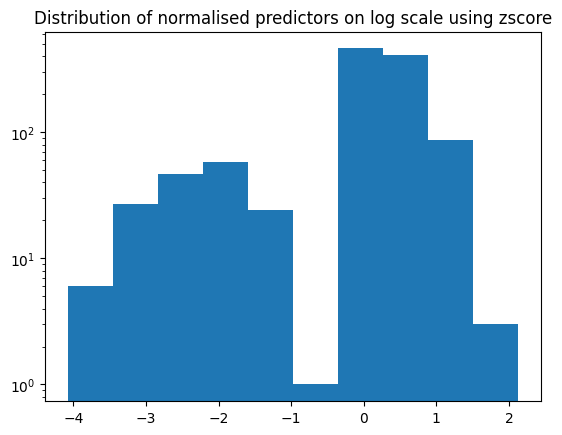

In [22]:
# Using the min and max predictor across all homings, create a new column that is a normalised version of the predictor
homing_data_normalised = {}
# extract the normalised predictor column to plot across all homings
extracted_norm_predictor = []

for idx, homing in enumerate(homing_data.values()):
    predictor = homing["predictor"]
    # normalised_predictor = robust_scale(predictor.to_numpy(), iqr, median)
    normalised_predictor = (predictor - mean) / std # zscore normalisation the predictors, mean and std are calculated from the whole dataset
    # need to fix that as data leakage, should be calculated from training data and test seperate 
    extracted_norm_predictor.append(normalised_predictor)
    new_column = pl.Series("normalised_predictor", normalised_predictor)
    homing = homing.with_columns(new_column)
    homing_data_normalised[idx] = homing
flatten_extracted_predictor = np.concatenate(extracted_predictor)
flatten_extracted_norm_predictor = np.concatenate(extracted_norm_predictor)
pl.Config.set_tbl_cols(10)
print(homing_data_normalised[0][:6]) # just show top few rows
plt.hist(flatten_extracted_norm_predictor)
plt.title("Distribution of normalised predictors on log scale using zscore")
plt.yscale('log')

### Just select the columns required E.G the frames and the predictor for each homing

In [23]:
# get frames first
homing_dic_thinned = {}

for idx, homing in enumerate(homing_data_normalised.values()):
    assert len(homing) > 0, "The homing data is empty, something is wrong with the data"
    homing_dic_thinned[idx] = homing.select(["frames", 'predictor', "normalised_predictor", "hsa", "hdir", "h_bar_north_a", "h_bar_south_a"])
print(homing_dic_thinned[0][:6]) # just show top few rows
    

shape: (6, 7)
┌────────┬───────────┬──────────────────────┬───────────┬──────────┬───────────────┬───────────────┐
│ frames ┆ predictor ┆ normalised_predictor ┆ hsa       ┆ hdir     ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ ---       ┆ ---                  ┆ ---       ┆ ---      ┆ ---           ┆ ---           │
│ i64    ┆ f64       ┆ f64                  ┆ f64       ┆ f64      ┆ f64           ┆ f64           │
╞════════╪═══════════╪══════════════════════╪═══════════╪══════════╪═══════════════╪═══════════════╡
│ 437105 ┆ 0.094751  ┆ 0.109438             ┆ -2.841595 ┆ 1.248201 ┆ 2.846737      ┆ -2.29099      │
│ 437106 ┆ 0.095435  ┆ 0.113215             ┆ -2.817909 ┆ 1.224059 ┆ 2.870676      ┆ -2.267845     │
│ 437107 ┆ 0.096351  ┆ 0.118273             ┆ -2.792178 ┆ 1.19773  ┆ 2.895581      ┆ -2.241672     │
│ 437108 ┆ 0.097625  ┆ 0.125314             ┆ -2.761971 ┆ 1.166649 ┆ 2.923594      ┆ -2.209842     │
│ 437109 ┆ 0.099415  ┆ 0.135197             ┆ -2.724273 ┆ 1.127635 ┆ 2.957454

## Create design matrix

In [24]:
# Initialise the design matrix and predictor vector
total_frames = sum([len(homing) for homing in homing_dic_thinned.values()]) # Total number of frames across all homings
total_neurons = frame_by_cluster_matrix.shape[1] # Total number of neurons
print(f"Shape of the design matrix is: {total_frames, total_neurons}")
design_matrix = np.zeros((total_frames, total_neurons))
predictor_vector = np.zeros((total_frames))
print("The shape of the predictor vector is: ", predictor_vector.shape)
assert design_matrix.shape[0] == predictor_vector.shape[0], "The design matrix and predictor vector are not the same length"

counter = 0
for idx, homing in enumerate(homing_dic_thinned.values()):
    # Extract
    frames = homing["frames"].to_numpy()
    predictor = homing["normalised_predictor"].to_numpy()
    # predictor = homing["predictor"].to_numpy()
    # predictor = homing["hsa"].to_numpy() # This is just for testing purposes
    # predictor = homing["hdir"].to_numpy() # This is just for testing purposes
    # predictor = homing["h_bar_north_a"].to_numpy() # This is just for testing purposes
    # predictor = homing["h_bar_south_a"].to_numpy() # This is just for testing purposes
    
    # Assign
    design_matrix[0 + counter: counter + len(frames)] = frame_by_cluster_matrix[frames[0]:frames[-1]+1]
    predictor_vector[0+counter:counter + len(frames)] = predictor
    counter += len(frames)

print("The design matrix and predictor vector are ready")
print(f"pred vector", predictor_vector)
print(f"matrix", design_matrix)
    

Shape of the design matrix is: (1124, 148)
The shape of the predictor vector is:  (1124,)
The design matrix and predictor vector are ready
pred vector [ 0.10943843  0.11321463  0.11827301 ... -1.615056   -1.60429106
 -1.59806523]
matrix [[ 0. 10.  0. ...  0.  0.  0.]
 [ 0. 10.  0. ...  0.  0.  0.]
 [ 0. 10.  0. ... 10.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [20. 10. 20. ...  0.  0.  0.]
 [20. 10. 20. ...  0.  0.  0.]]


In [25]:
# Handle nans
import numpy as np
import pandas as pd

# REplace values greater than 2.5 or less than -2.5 with nans
# predictor_vector[predictor_vector > 2.5] = np.nan
# predictor_vector[predictor_vector < -2.5] = np.nan

# # Convert the numpy array to a pandas series
# series = pd.Series(predictor_vector)

# # Interpolate missing values
# interpolated_series = series.interpolate(method='linear', limit_direction='both')

# # Convert back to numpy array if needed
# interpolated_pred = interpolated_series.to_numpy()

# print(interpolated_pred)

data = predictor_vector

Q1 = np.percentile(data, 25, interpolation='midpoint')
Q3 = np.percentile(data, 75, interpolation='midpoint')
IQR = Q3 - Q1

# Identify outliers
outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))

# Replace outliers with NaN
data[outliers] = np.nan

data_interpolated = np.interp(
    x=np.arange(len(data)),
    xp=np.arange(len(data))[~np.isnan(data)],
    fp=data[~np.isnan(data)]
)

def moving_average(data, window_size):
    """ Compute the moving average of a 1D array. """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Choose a window size
window_size = 3

# Smooth the data
data_smoothed = moving_average(data_interpolated, window_size)

# To maintain the same size as the original array after smoothing,
# you can pad the result with the original data or perform edge handling.
# Here's an example of padding with edge values:
pad_width = window_size // 2
data_padded = np.pad(data_smoothed, (pad_width, pad_width), mode='edge')



C:\Users\laurence\AppData\Local\Temp\ipykernel_16964\2910705422.py:22: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  Q1 = np.percentile(data, 25, interpolation='midpoint')
C:\Users\laurence\AppData\Local\Temp\ipykernel_16964\2910705422.py:23: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  Q3 = np.percentile(data, 75, interpolation='midpoint')


## First overfit

In [26]:
# Try with zscore normalisation across neurons
from scipy import stats
zmatrix = stats.zscore(design_matrix, axis=0) # Zscore the design matrix across the columns
zmatrix = np.nan_to_num(zmatrix) # Replace nans with zeros

print("The shape of the design matrix is", design_matrix.shape)
print("The shape of the predictor vector is", predictor_vector.shape)
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(design_matrix, data_padded)
r2 = reg.score(design_matrix, data_padded)
print("The R2 score without PCA is: ", r2)
predictions = reg.predict(design_matrix)

# # Try to zscore the design matrix and see if it improves the R2 score
reg_zscore = LinearRegression().fit(zmatrix, data_padded)
zr2 = reg_zscore.score(zmatrix, data_padded)
print("The R2 score with zscore and no PCA is: ", zr2)

# # # Now try with PCA to reduce the dimensionality of the design matrix
# from sklearn.decomposition import PCA
# pca_matrix = PCA(n_components=3).fit_transform(zmatrix)
# print("The shape of the design matrix after PCA is: ", zmatrix.shape)
# pca_reg = LinearRegression().fit(pca_matrix, stats.zscore(data_padded))
# pca_r2 = pca_reg.score(pca_matrix, stats.zscore(data_padded))
# print("The R2 score after PCA is: ", pca_r2)


The shape of the design matrix is (1124, 148)
The shape of the predictor vector is (1124,)
The R2 score without PCA is:  0.5898262735056929
The R2 score with zscore and no PCA is:  0.5903221788068245


# Try split out x and y components to handle circular variable

In [27]:
from sklearn.multioutput import MultiOutputRegressor
pred_multi = np.array([np.sin(interpolated_pred), np.cos(interpolated_pred)]).T
regressor = MultiOutputRegressor(LinearRegression()).fit(design_matrix, pred_multi)
print("The R2 score with multioutput regressor is: ", regressor.score(design_matrix, pred_multi))
predictions_multi = regressor.predict(design_matrix)
angle_predictions = np.arctan2(predictions_multi[:, 0], predictions_multi[:, 1])
plt.scatter(interpolated_pred, angle_predictions)
plt.xlabel("Real angle")
plt.ylabel("Predicted angle")

residuals = interpolated_pred - angle_predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


# Now plot the predictions next to the real on a scatter plot


NameError: name 'interpolated_pred' is not defined

# Create some plots of model fit

In [ ]:
import matplotlib.pyplot as plt

residuals = interpolated_pred - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(interpolated_pred, predictions, alpha=0.5)
plt.plot(interpolated_pred, interpolated_pred, color='red')  # Line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

#  BY SPACE -  Use the big dic to index into spike cluster matrix and create design matrix

In [ ]:
# # Init the design matrix and container dictionaries
# total_trials = len(extracted_info)
# total_neurons = frame_by_cluster_matrix.shape[1]
# design_matrix = np.zeros((total_trials, total_neurons))
# print(f"The shape of the design matrix is: {design_matrix.shape}")
# dic_matrix = {} # A matrix containing the design matrix for each spatial bin of the homings
# pred_dic_for_matrix = {}

# # Loop through each bin and create design matrix and predictor vector

# for homing_chunk, bin in enumerate(bins):
#     trials = big_dic[homing_chunk]
#     pred_vector = []
#     for trial_idx in trials:
        
#         # Get the frames and predictors for each trial
#         frames = trials[trial_idx].select("frames").to_numpy().reshape(-1)
#         predictors = trials[trial_idx].select("normalised_predictor").to_numpy().reshape(-1)
#         # print("Here you can see how different the predictors are witin a bin of a trial")
#         # print(predictors)
#         assert len(frames) == len(predictors), "The number of frames and predictors are not the same"
        
#         # Compute statistic for the predictor vector across all the frames in that trial
#         median = np.nanmedian(predictors)
#         pred_vector.append(median)
        
#         spike_counts = np.zeros(total_neurons)
#         for frame in frames:
#             spike_counts += frame_by_cluster_matrix[frame] # TODO - Check for off by one error
#         design_matrix[trial_idx] = spike_counts
#     assert design_matrix.shape[0] == len(pred_vector), f"The length of the design matrix {design_matrix.shape[0]} and the predictor vector {len(pred_vector)} are not the same"
#     dic_matrix[homing_chunk] = design_matrix
#     pred_dic_for_matrix[homing_chunk] = pred_vector
#     # print(len(pred_vector))
#     # print(len(design_matrix))
#     # assert len(dic_matrix[homing_chunk]) == len(pred_dic_for_matrix[homing_chunk]), "The length of the design matrix and the predictor vector are not the same"

# print(f"The len of the dictionary containing all of the predictor vectors is: {pred_dic_for_matrix.keys()}")
# print(len(dic_matrix[10]))

# for i in range(32):
#     print(f"bin {i} has {pred_dic_for_matrix[i]} values")
    
# # print(dic_matrix.keys())
# # print(dic_matrix[0].shape)
# # print(dic_matrix[0])

# # NOTE
# # THis could mean for example if the second trial does not go into that bin, then the neural firing will be all zeros
# # either remove this, leave it in, or leave it in and regularize it so it doesn't affefct the model too muich

## Process the design matrices - Zscore across trials for individual neurons

In [ ]:
# from scipy import stats

# zscore_design_matrix = {}
# for key in dic_matrix:
#     homing_chunk = dic_matrix[key]
#     zscore_chunk = stats.zscore(homing_chunk, axis=0, nan_policy='raise') # Zscore the design matrix across the columns
#     assert homing_chunk.shape == zscore_chunk.shape, "The zscored design matrix is not the same shape as the original design matrix"
#     # Replace NaNs with 0s
#     zscore_chunk = np.nan_to_num(zscore_chunk)
#     assert not np.isnan(zscore_chunk).any(), "There are NaNs in the zscored design matrix"
#     zscore_design_matrix[key] = zscore_chunk
    

## Now put design matrix that has been zscored into PCA

In [ ]:
# from sklearn import decomposition

# pca_zscore_design_matrix = {}
# for key in zscore_design_matrix:
#     homing_chunk = zscore_design_matrix[key]
#     pca = decomposition.PCA(n_components=3)
#     pca_chunk = pca.fit_transform(homing_chunk)
#     pca_zscore_design_matrix[key] = pca_chunk

## Check the predictors

# Fit

In [ ]:
# print("The length of the pca zscore design matrix is: ", len(pca_zscore_design_matrix))
# print("The length of the predictor dictionary is: ", len(pred_dic_for_matrix))
# for bin in range(4, len(bins)):
#     print(bin)
#     X = pca_zscore_design_matrix[bin]
#     y = pred_dic_for_matrix[bin]
#     print(X)
#     print(y)
#     assert X.shape[0] == len(y), "The number of rows in the design matrix and the predictor vector are not the same"